Dataset: 1797 samples, 64 features
Classes: [0 1 2 3 4 5 6 7 8 9]


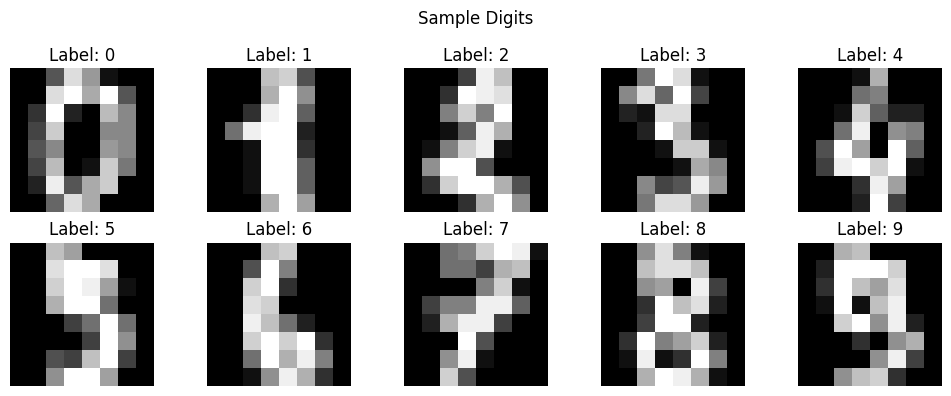

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

np.random.seed(42)

digits = load_digits()
X = digits.data / 16.0 
y = digits.target

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {np.unique(y)}")

# visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.suptitle('Sample Digits')
plt.tight_layout()
plt.show()

In [2]:
def one_hot(y, n_classes):
    n = len(y)
    oh = np.zeros((n, n_classes))
    oh[np.arange(n), y] = 1
    return oh

Y = one_hot(y, n_classes=10)
print(f"y shape: {y.shape} → Y shape: {Y.shape}")

y shape: (1797,) → Y shape: (1797, 10)


In [3]:
X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X, Y, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1437, 64), Test: (360, 64)


In [4]:
def initialize_params(layer_dims):
    params = {}
    for l in range(1, len(layer_dims)):
        params[f'W{l}'] = np.random.randn(layer_dims[l-1], layer_dims[l]) * np.sqrt(2 / layer_dims[l-1])
        params[f'b{l}'] = np.zeros((1, layer_dims[l]))
    return params

layer_dims = [64, 128, 64, 10]
params = initialize_params(layer_dims)

for k, v in params.items():
    print(f"{k}: {v.shape}")

W1: (64, 128)
b1: (1, 128)
W2: (128, 64)
b2: (1, 64)
W3: (64, 10)
b3: (1, 10)


In [5]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [6]:
z = np.array([[2.0, 1.0, 0.5, 3.0]])
probs = softmax(z)
print(f"Softmax output: {probs}")
print(f"Sum: {probs.sum():.4f}")

Softmax output: [[0.23205671 0.08536889 0.05177885 0.63079554]]
Sum: 1.0000


In [7]:
def forward_pass(X, params):
    cache = {'A0': X}

    cache['Z1'] = cache['A0'] @ params['W1'] + params['b1']
    cache['A1'] = relu(cache['Z1'])

    cache['Z2'] = cache['A1'] @ params['W2'] + params['b2']
    cache['A2'] = relu(cache['Z2'])

    cache['Z3'] = cache['A2'] @ params['W3'] + params['b3']
    cache['A3'] = softmax(cache['Z3'])

    return cache['A3'], cache

In [8]:
def cross_entropy_loss(Y_true, Y_pred):
    Y_pred = np.clip(Y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(np.sum(Y_true * np.log(Y_pred), axis=1))

In [9]:
def backward_pass(X, Y_true, params, cache):
    n = X.shape[0]
    grads = {}

    grads['dZ3'] = cache['A3'] - Y_true                          # (n, 10)
    grads['dW3'] = (1/n) * cache['A2'].T @ grads['dZ3']
    grads['db3'] = (1/n) * np.sum(grads['dZ3'], axis=0, keepdims=True)

    grads['dA2'] = grads['dZ3'] @ params['W3'].T
    grads['dZ2'] = grads['dA2'] * relu_derivative(cache['Z2'])
    grads['dW2'] = (1/n) * cache['A1'].T @ grads['dZ2']
    grads['db2'] = (1/n) * np.sum(grads['dZ2'], axis=0, keepdims=True)

    grads['dA1'] = grads['dZ2'] @ params['W2'].T
    grads['dZ1'] = grads['dA1'] * relu_derivative(cache['Z1'])
    grads['dW1'] = (1/n) * cache['A0'].T @ grads['dZ1']
    grads['db1'] = (1/n) * np.sum(grads['dZ1'], axis=0, keepdims=True)

    return grads

In [10]:
def update_params(params, grads, learning_rate):
    n_layers = len(params) // 2
    for l in range(1, n_layers + 1):
        params[f'W{l}'] -= learning_rate * grads[f'dW{l}']
        params[f'b{l}'] -= learning_rate * grads[f'db{l}']
    return params

In [11]:
def predict(X, params):
    probs, _ = forward_pass(X, params)
    return np.argmax(probs, axis=1)

# initialize
params = initialize_params(layer_dims)
learning_rate = 0.01
epochs = 500
loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(epochs):
    # forward
    Y_pred, cache = forward_pass(X_train, params)

    # loss
    loss = cross_entropy_loss(Y_train, Y_pred)
    loss_history.append(loss)

    # backward
    grads = backward_pass(X_train, Y_train, params, cache)

    # update
    params = update_params(params, grads, learning_rate)

    # accuracy
    train_acc = np.mean(predict(X_train, params) == y_train)
    val_acc   = np.mean(predict(X_test, params) == y_test)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch   50 | Loss: 2.0899 | Train Acc: 0.2958 | Val Acc: 0.2750
Epoch  100 | Loss: 1.8032 | Train Acc: 0.5581 | Val Acc: 0.5694
Epoch  150 | Loss: 1.5340 | Train Acc: 0.7258 | Val Acc: 0.7139
Epoch  200 | Loss: 1.3004 | Train Acc: 0.8051 | Val Acc: 0.8139
Epoch  250 | Loss: 1.1022 | Train Acc: 0.8455 | Val Acc: 0.8472
Epoch  300 | Loss: 0.9384 | Train Acc: 0.8706 | Val Acc: 0.8722
Epoch  350 | Loss: 0.8058 | Train Acc: 0.8935 | Val Acc: 0.8722
Epoch  400 | Loss: 0.6984 | Train Acc: 0.9026 | Val Acc: 0.8889
Epoch  450 | Loss: 0.6120 | Train Acc: 0.9123 | Val Acc: 0.8972
Epoch  500 | Loss: 0.5424 | Train Acc: 0.9186 | Val Acc: 0.9083


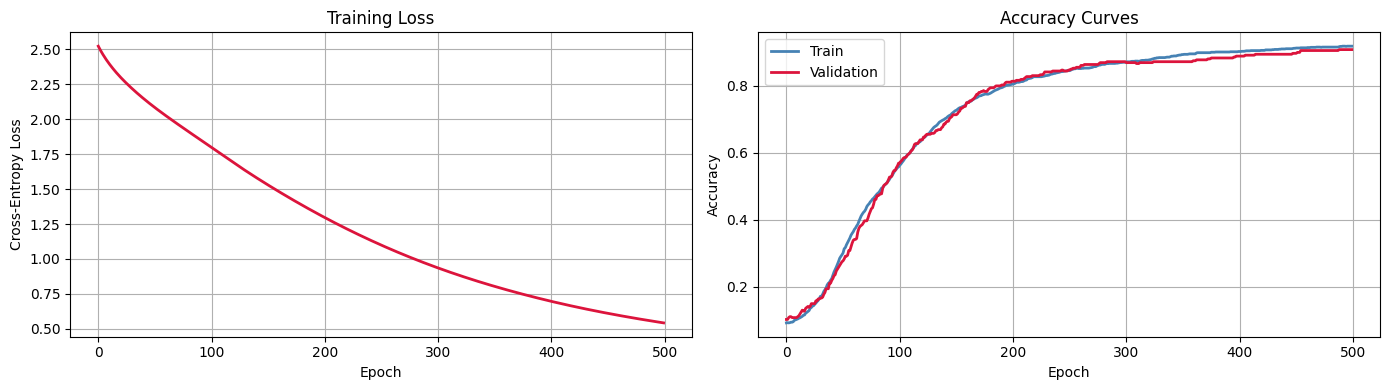


Final Test Accuracy: 0.9083


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss_history, color='crimson', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True)

axes[1].plot(train_acc_history, color='steelblue', linewidth=2, label='Train')
axes[1].plot(val_acc_history, color='crimson', linewidth=2, label='Validation')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracy: {val_acc_history[-1]:.4f}")